
# **One-Dimensional (1D) Random Walk** 

---

## 1. Introduction

A **Random Walk** is a mathematical model that describes a path consisting of a series of random steps.
At each time step, a "walker" moves in a randomly chosen direction with no memory of its previous position.

> **Analogy:** Imagine a drunk person standing at a lamppost. At each second, they randomly take a step
> left or right (in 1D), or in any direction (in 2D/3D). The path they trace is a random walk.

This concept is one of the most fundamental models in **probability theory**, **statistical physics**,
and **applied mathematics**.

---

## 2. Mathematical Foundation

### 2.1 Position After N Steps

Let $X_i$ represent the displacement at step $i$, where each $X_i$ is a random variable.

The **total position** after $N$ steps is:

$$S_N = X_1 + X_2 + X_3 + \cdots + X_N = \sum_{i=1}^{N} X_i$$


### 2.3 Mean Squared Displacement (MSD)

The **MSD** is the average of the squared distance over many independent simulations:

$$\text{MSD}(t) = \langle r^2(t) \rangle = \langle x^2(t) + y^2(t) + z^2(t) \rangle$$

For a standard random walk: $\text{MSD} \propto N$ (linear in number of steps)

---

## 3. Types of Random Walk by Dimension

---

### 3.1 One-Dimensional (1D) Random Walk

#### Definition
The walker moves along a straight line (number line). At each step:

$$X_i = \begin{cases} +1 & \text{with probability } p = 0.5 \\ -1 & \text{with probability } q = 0.5 \end{cases}$$

#### Position Update Rule

$$S_n = S_{n-1} + X_n, \quad S_0 = 0$$

#### Visualization
- X-axis → Time (step number)
- Y-axis → Position of walker

#### Properties
| Property | Value |
|---|---|
| Directions | 2 (left / right) |
| Step choices | +1, −1 |
| Mean position | 0 |
| RMS distance | $\sqrt{N}$ |

---







## 4. Important Statistical Properties

### 4.1 Gaussian Distribution (Central Limit Theorem)
As $N \to \infty$, the position $S_N$ follows a **Normal (Gaussian) distribution**:

$$P(S_N = x) \approx \frac{1}{\sqrt{2\pi N}} \exp\left(-\frac{x^2}{2N}\right)$$

### 4.2 Diffusion Coefficient
The random walk is directly related to **diffusion**:

$$\text{MSD} = 2dDt$$

where:
- $d$ = number of dimensions
- $D$ = diffusion coefficient
- $t$ = number of time steps



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


In [9]:
rng = np.random.default_rng(seed=123045)
def random_walk_1D(no_of_steps: int):
    steps = rng.choice([1, -1], size=no_of_steps)
    
    # Cumulative sum adds them all up step-by-step instantly!
    walk = np.concatenate([[0], np.cumsum(steps)])
    
    return walk[-1], walk


Min : min(walk)
Max: 9067


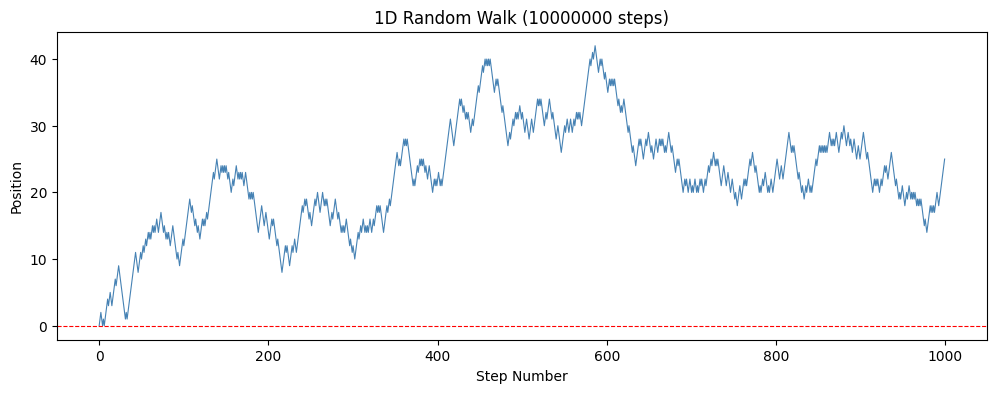

In [11]:
no_of_steps = 10000000
position, walk = random_walk_1D(no_of_steps)
print(f"Min : min(walk)")
print(f"Max: {max(walk)}")

plt.figure(figsize=(12, 4))
plt.plot(walk[:1000], color='steelblue', linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)  # origin line
plt.title(f'1D Random Walk ({no_of_steps} steps)')
plt.xlabel('Step Number')
plt.ylabel('Position')
plt.show()

* Random walk will return to its origin with probabilty of 1

In [4]:
print(f"Mean : {np.mean(walk)}")
print(f"Standard Deviation : {np.std(walk):.2f}")
print(f"Variance : {np.var(walk):.2f}")

Mean : -5.524475524475524
Standard Deviation : 20.69
Variance : 428.27


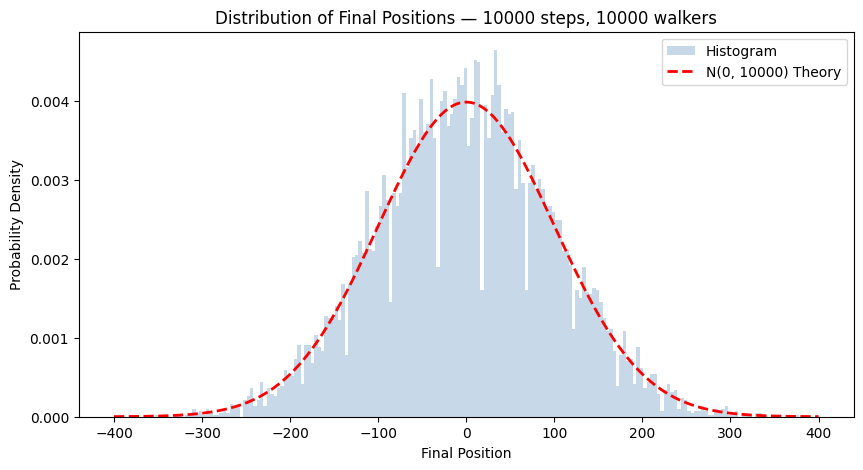

In [5]:
from scipy.stats import norm, gaussian_kde

num_walkers = 10000
N = 10000

steps = np.random.choice([-1, 1], size=(num_walkers, N))
final_positions = steps.sum(axis=1)

# KDE smoothing
kde = gaussian_kde(final_positions)
x = np.linspace(-4 * np.sqrt(N), 4 * np.sqrt(N), 500)
theoretical = norm.pdf(x, loc=0, scale=np.sqrt(N))

plt.figure(figsize=(10, 5))

# Histogram underneath (for reference)
plt.hist(final_positions, bins=200, density=True,
         alpha=0.3, color='steelblue', label='Histogram')

# KDE smooth curve

# Theoretical Gaussian
plt.plot(x, theoretical, 'r--', linewidth=2, label=f'N(0, {N}) Theory')

plt.title(f'Distribution of Final Positions — {N} steps, {num_walkers} walkers')
plt.xlabel('Final Position')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

* This Proves that as N goes to Infinity the distribution follows a Guassian Curve.

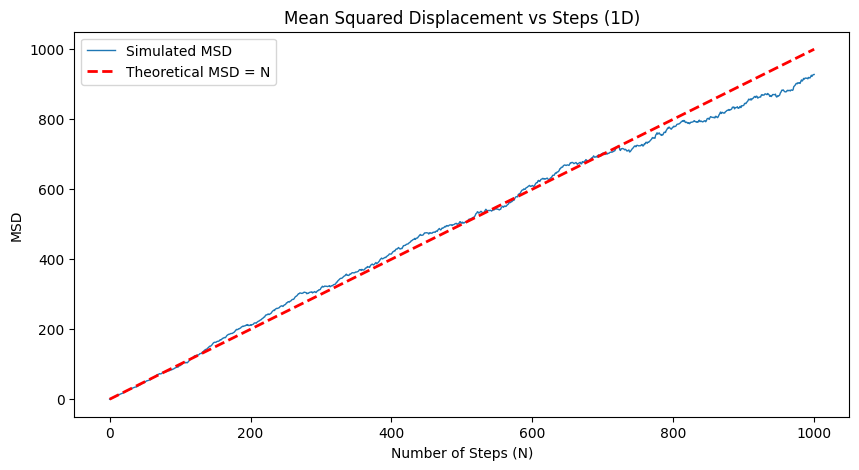

In [6]:
num_walkers = 500
N = 1000

# Collect squared distances at each step
all_sq_distances = np.zeros((num_walkers, N+1))

for i in range(num_walkers):
    _, walk = random_walk_1D(N)
    all_sq_distances[i] = np.array(walk)**2

# MSD = average squared distance across all walkers at each step
msd = np.mean(all_sq_distances, axis=0)
steps = np.arange(N+1)

plt.figure(figsize=(10, 5))
plt.plot(steps, msd, label='Simulated MSD', linewidth=1)
plt.plot(steps, steps, 'r--', label='Theoretical MSD = N', linewidth=2)
plt.title('Mean Squared Displacement vs Steps (1D)')
plt.xlabel('Number of Steps (N)')
plt.ylabel('MSD')
plt.legend()
plt.show()

* The Theoretical MSD and Simulated MSD are approximately equal